# Dynamic Black Hole Imaging with StarWarps

This notebook demonstrates the **StarWarps** algorithm (Bouman et al. 2017, arXiv:1711.01357)
for reconstructing a time-varying video of a black hole from sparse interferometric measurements.

All code uses our self-contained `src/` modules — **no ehtim dependency**.

We compare two methods:

| Method | Temporal coupling | Algorithm |
|--------|------------------|----------|
| **Static per-frame** | None | Independent Gaussian MAP per frame |
| **StarWarps** | Gaussian Markov model | Forward-backward message passing + EM |

**Key insight**: Individual frames are severely under-determined (28 baselines for 900 pixels).
StarWarps borrows information across time to improve each frame's reconstruction.

In [1]:
import os, sys
import numpy as np
import matplotlib.pyplot as plt
import json
import time as timer

# Add task root to path
TASK_DIR = os.path.abspath(os.path.join(os.getcwd(), '..'))
sys.path.insert(0, TASK_DIR)

%matplotlib inline
plt.rcParams.update({'font.size': 10, 'figure.dpi': 120})

from src.preprocessing import load_observation, load_metadata, load_ground_truth, build_per_frame_models
from src.physics_model import (
    DFTForwardModel, compute_visibilities, gauss_image_covariance,
    affine_motion_basis, calc_warp_matrix, product_gaussians_lem1, product_gaussians_lem2,
)
from src.solvers import StaticPerFrameSolver, StarWarpsSolver
from src.visualization import compute_metrics, compute_video_metrics, print_metrics_table

print('All modules loaded successfully (no ehtim dependency)')

All modules loaded successfully (no ehtim dependency)


## 1. Ground-Truth Video & Observation Data

We load a synthetic **rotating crescent** (SgrA*-like) observed by the EHT 2017 array.
The bright spot rotates 90° over 6 hours across 12 frames.

In [2]:
# Load data
data_dir = os.path.join(TASK_DIR, 'data')
obs = load_observation(data_dir)
meta = load_metadata(data_dir)
gt = load_ground_truth(TASK_DIR)

N = meta['N']
psize = meta['pixel_size_rad']
n_frames = meta['n_frames']
total_flux = meta['total_flux']
frame_times = obs['frame_times']

print(f'Image size:       {N} x {N} pixels')
print(f'Pixel size:       {meta["pixel_size_uas"]:.1f} μas')
print(f'Number of frames: {n_frames}')
print(f'Observation:      {meta["obs_duration_hours"]:.0f} hours')
print(f'Total flux:       {total_flux:.1f} Jy/frame')
print(f'Baselines/frame:  {meta["baselines_per_frame"]}')
print(f'Source:           {meta["source_name"]} (RA={meta["source_ra_deg"]:.3f}°, Dec={meta["source_dec_deg"]:.3f}°)')
print(f'Stations:         {meta["n_stations"]} ({" ".join(meta["station_names"])})')

Image size:       30 x 30 pixels
Pixel size:       3.4 μas
Number of frames: 12
Observation:      6 hours
Total flux:       2.0 Jy/frame
Baselines/frame:  28
Source:           SgrA* (RA=266.417°, Dec=-28.992°)
Stations:         8 (ALMA APEX JCMT SMA SMT LMT PV SPT)


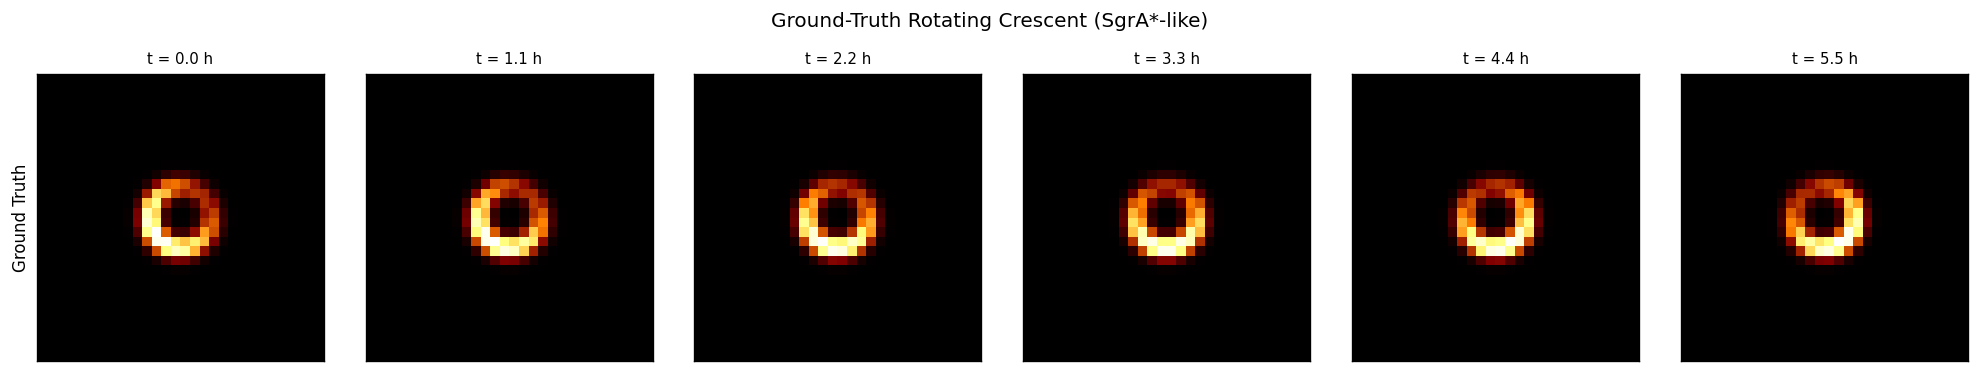

Each frame sums to 2.000 Jy (total flux = 2.0 Jy)


In [3]:
# Display ground-truth video frames
n_show = min(6, n_frames)
step = max(1, n_frames // n_show)
show_idx = list(range(0, n_frames, step))[:n_show]

fig, axes = plt.subplots(1, n_show, figsize=(2.8 * n_show, 3))
for j, idx in enumerate(show_idx):
    ax = axes[j]
    ax.imshow(gt[idx], cmap='afmhot', origin='lower', vmin=0, vmax=gt.max())
    ax.set_title(f't = {frame_times[idx]:.1f} h', fontsize=9)
    ax.set_xticks([]); ax.set_yticks([])
    if j == 0:
        ax.set_ylabel('Ground Truth', fontsize=10)

fig.suptitle('Ground-Truth Rotating Crescent (SgrA*-like)', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

print(f'Each frame sums to {gt[0].sum():.3f} Jy (total flux = {total_flux} Jy)')

## 2. UV-Coverage & Forward Model

Each frame has its own UV-coverage determined by Earth rotation at that epoch.
The forward model is a DFT: $\mathbf{y}_t = \mathbf{A}_t \mathbf{x}_t + \mathbf{n}_t$

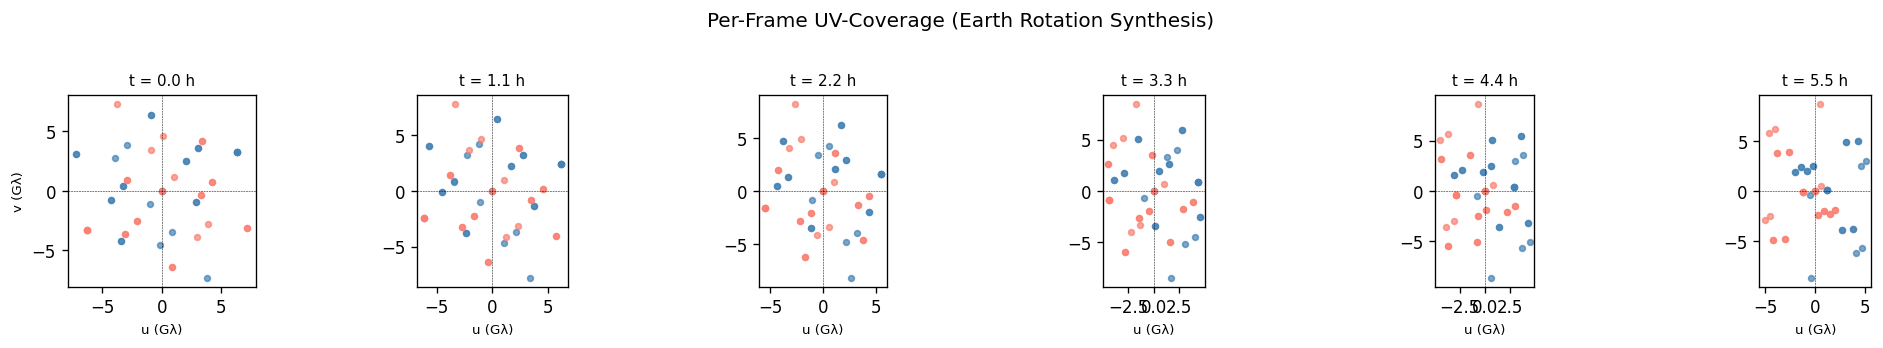

In [4]:
# Plot UV-coverage for selected frames
fig, axes = plt.subplots(1, n_show, figsize=(2.8 * n_show, 2.8))
for j, idx in enumerate(show_idx):
    ax = axes[j]
    uv = obs['uv'][idx] / 1e9  # convert to Gλ
    ax.scatter(uv[:, 0], uv[:, 1], s=12, c='steelblue', alpha=0.7)
    ax.scatter(-uv[:, 0], -uv[:, 1], s=12, c='salmon', alpha=0.7)
    ax.set_aspect('equal')
    ax.set_title(f't = {frame_times[idx]:.1f} h', fontsize=9)
    ax.set_xlabel('u (Gλ)', fontsize=8)
    if j == 0:
        ax.set_ylabel('v (Gλ)', fontsize=8)
    ax.axhline(0, color='k', lw=0.3, ls='--')
    ax.axvline(0, color='k', lw=0.3, ls='--')

fig.suptitle('Per-Frame UV-Coverage (Earth Rotation Synthesis)', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

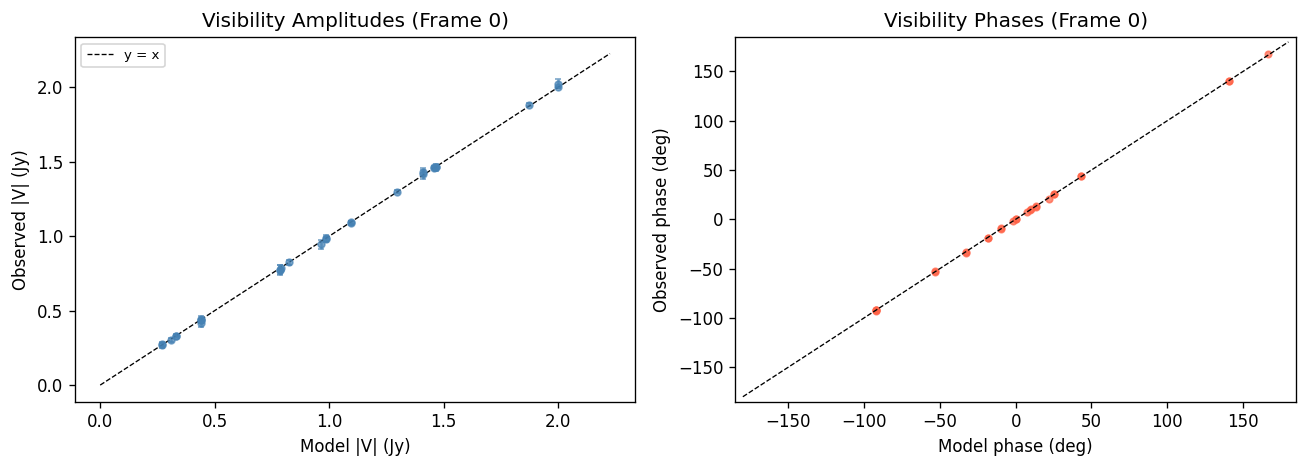

DFT matrix A: (28, 900) (complex)
χ² / DOF = 0.58 (should be ~1 for well-calibrated data)


In [5]:
# Build per-frame DFT forward models
models = build_per_frame_models(obs, meta)

# Demonstrate forward model on frame 0
A0 = models[0].matrix
vis_pred = compute_visibilities(gt[0].ravel(), A0)
vis_obs = obs['vis'][0]
sigma = obs['sigma'][0]

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Amplitude comparison
ax = axes[0]
ax.errorbar(np.abs(vis_pred), np.abs(vis_obs), yerr=sigma,
            fmt='o', markersize=4, alpha=0.7, capsize=2, color='steelblue')
lim = max(np.abs(vis_pred).max(), np.abs(vis_obs).max()) * 1.1
ax.plot([0, lim], [0, lim], 'k--', lw=0.8, label='y = x')
ax.set_xlabel('Model |V| (Jy)')
ax.set_ylabel('Observed |V| (Jy)')
ax.set_title('Visibility Amplitudes (Frame 0)')
ax.legend(fontsize=8)

# Phase comparison
ax = axes[1]
ax.scatter(np.angle(vis_pred, deg=True), np.angle(vis_obs, deg=True),
           s=15, alpha=0.7, c='tomato')
ax.plot([-180, 180], [-180, 180], 'k--', lw=0.8)
ax.set_xlabel('Model phase (deg)')
ax.set_ylabel('Observed phase (deg)')
ax.set_title('Visibility Phases (Frame 0)')
ax.set_xlim(-185, 185); ax.set_ylim(-185, 185)

plt.tight_layout()
plt.show()

chi2 = np.mean(np.abs((vis_obs - vis_pred) / sigma)**2)
print(f'DFT matrix A: {A0.shape} (complex)')
print(f'χ² / DOF = {chi2:.2f} (should be ~1 for well-calibrated data)')

## 3. Prior & Process Noise

StarWarps uses a Gaussian prior $\mathbf{x}_t \sim \mathcal{N}(\boldsymbol{\mu}, \boldsymbol{\Lambda})$
with a power-law Fourier-domain covariance:

$$\boldsymbol{\Lambda} = \text{frac}^2 \cdot \text{diag}(\mathbf{x}) \cdot \left(\mathbf{F}^H \text{diag}(|\mathbf{uv}|^{-\alpha}) \mathbf{F}\right) \cdot \text{diag}(\mathbf{x})$$

The prior mean uses a **super-Gaussian** profile $\exp(-(r/\sigma)^6)$ with a 5% floor. This is flatter than a standard Gaussian in the centre (reducing centre-bright reconstruction bias), while maintaining smooth edge falloff needed for stable warp optimisation in the EM M-step.

The process noise $\mathbf{Q} = \sigma^2 \mathbf{I}$ controls how much the image can change between frames.

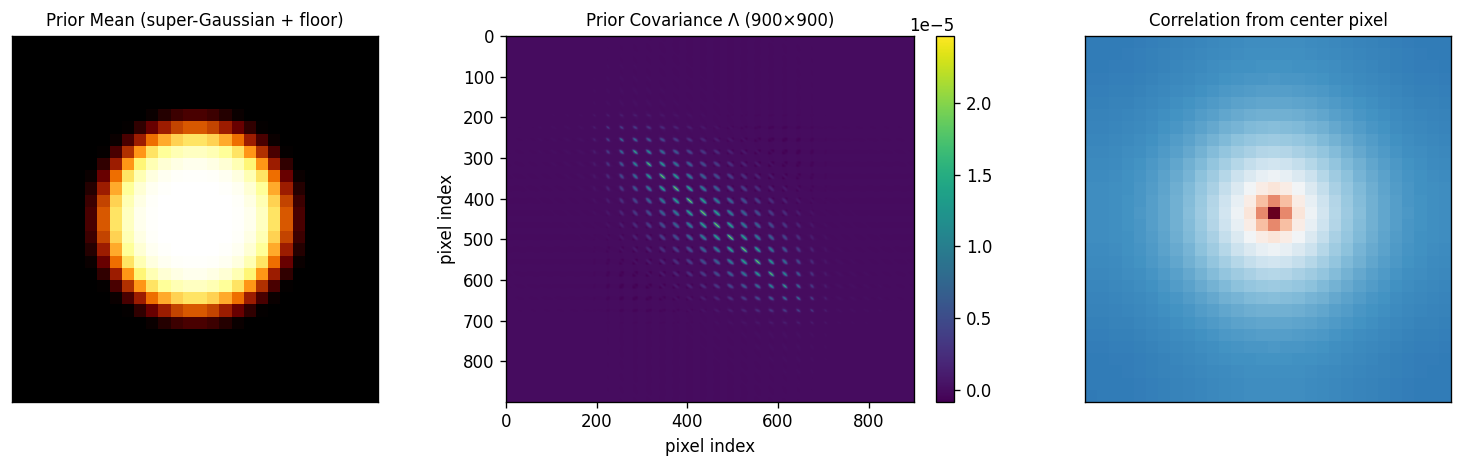

Prior mean flux: 2.00 Jy
Prior: super-Gaussian n=6, FWHM=50 μas, 5% floor
Prior covariance: (900, 900), rank ≈ 899
Process noise variance: 1.0e-07


In [6]:
npixels = N * N

# Prior mean: super-Gaussian (flat-top) with floor
# exp(-(r/σ)^6) is flat in the centre and rolls off smoothly at edges.
# A 5% floor prevents near-zero edge values that would make the
# covariance singular (Λ ∝ diag(imvec) · BaseCov · diag(imvec)).
fwhm_uas = 50.0
n_pow = 6
uas2rad = np.pi / (180.0 * 3600.0 * 1e6)
sigma_sg = (fwhm_uas * uas2rad) / (2.0 * (np.log(2.0))**(1.0 / n_pow))

xlist = np.arange(0, -N, -1) * psize + (psize * N) / 2.0 - psize / 2.0
ylist = np.arange(0, -N, -1) * psize + (psize * N) / 2.0 - psize / 2.0
xx, yy = np.meshgrid(xlist, ylist)
rr = np.sqrt(xx**2 + yy**2)
sg_blob = np.exp(-(rr / sigma_sg)**n_pow)
sg_blob = np.maximum(sg_blob, 0.05 * sg_blob.max())  # 5% floor
prior_mean = (sg_blob / sg_blob.sum() * total_flux).ravel()

# Prior covariance: power-law Fourier spectrum
# Λ = frac² * diag(x) * F^H diag(|uv|^(-α)) F * diag(x)
prior_cov = gauss_image_covariance(N, psize, prior_mean, power_dropoff=2.0, frac=0.5)

# Process noise: small diagonal (allows intensity variation between frames)
variance_img_diff = 1e-7
process_noise_cov = variance_img_diff * np.eye(npixels)

# Visualize prior
fig, axes = plt.subplots(1, 3, figsize=(13, 4))

ax = axes[0]
ax.imshow(prior_mean.reshape(N, N), cmap='afmhot', origin='lower')
ax.set_title('Prior Mean (super-Gaussian + floor)', fontsize=10)
ax.set_xticks([]); ax.set_yticks([])

ax = axes[1]
im = ax.imshow(prior_cov, cmap='viridis', aspect='auto')
ax.set_title(f'Prior Covariance Λ ({npixels}×{npixels})', fontsize=10)
ax.set_xlabel('pixel index'); ax.set_ylabel('pixel index')
plt.colorbar(im, ax=ax, fraction=0.046)

ax = axes[2]
# Correlation from center pixel: corr[i] = Cov[c,i] / sqrt(Cov[c,c]*Cov[i,i])
# Use the actual image center (N//2, N//2), not npixels//2 which is (N//2, 0)
center = (N // 2) * N + (N // 2)
cov_diag = np.diag(prior_cov)
corr_row = prior_cov[center, :] / np.sqrt(prior_cov[center, center] * cov_diag + 1e-30)
ax.imshow(corr_row.reshape(N, N), cmap='RdBu_r', origin='lower', vmin=-0.3, vmax=1)
ax.set_title('Correlation from center pixel', fontsize=10)
ax.set_xticks([]); ax.set_yticks([])

plt.tight_layout()
plt.show()

print(f'Prior mean flux: {prior_mean.sum():.2f} Jy')
print(f'Prior: super-Gaussian n={n_pow}, FWHM={fwhm_uas:.0f} μas, 5% floor')
print(f'Prior covariance: {prior_cov.shape}, rank ≈ {np.linalg.matrix_rank(prior_cov, tol=1e-12)}')
print(f'Process noise variance: {variance_img_diff:.1e}')

## 4. Motion Basis & Warp Matrix

StarWarps models inter-frame motion via an affine warp in the Fourier domain:

$$\mathbf{x}_t = \mathbf{W}(\boldsymbol{\theta}) \, \mathbf{x}_{t-1} + \mathbf{w}_t$$

The warp matrix $\mathbf{W}$ is computed via phase shifts:
$\mathbf{W} = \mathbf{S}(\boldsymbol{\theta}_\text{init})^{-1} \mathbf{S}(\boldsymbol{\theta})$

where $\mathbf{S}(\boldsymbol{\theta})$ is a Fourier-domain shift matrix parameterized by 6 affine motion parameters.

Affine motion basis:
  init_x shape:     (30, 30, 1)
  flowbasis_x shape: (30, 30, 6) (N×N×6)
  init_theta:       [1 0 0 0 1 0] (identity transform)

Warp matrix at identity: (900, 900)
  ||W - I||_F = 2.64e-13 (should be ~0)


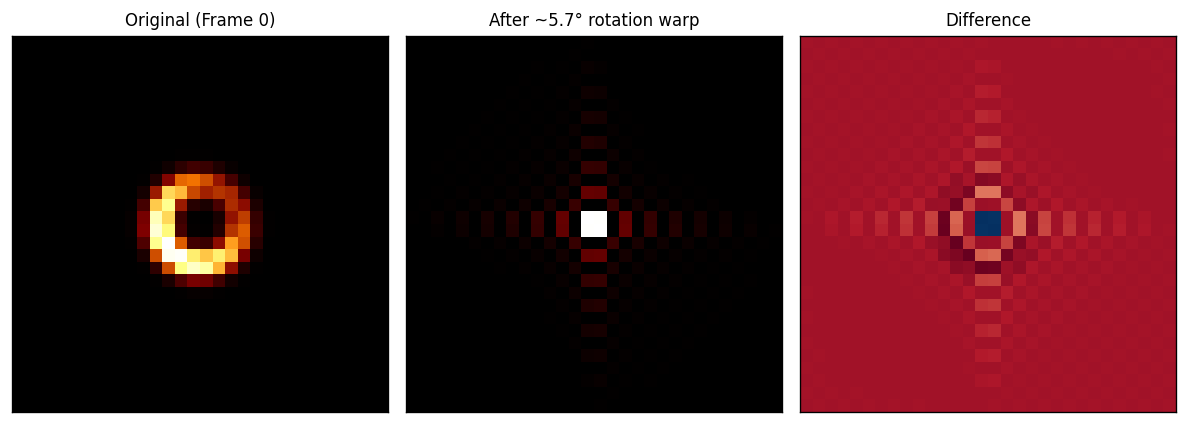

In [7]:
# Set up affine motion basis (6 DOF: 2×2 linear + 2 translation)
init_x, init_y, fb_x, fb_y, init_theta = affine_motion_basis(N, psize)

print('Affine motion basis:')
print(f'  init_x shape:     {init_x.shape}')
print(f'  flowbasis_x shape: {fb_x.shape} (N×N×6)')
print(f'  init_theta:       {init_theta} (identity transform)')

# At identity theta, warp matrix should be identity
W_identity = calc_warp_matrix(N, psize, init_theta, init_x, init_y,
                              fb_x, fb_y, init_theta)

print(f'\nWarp matrix at identity: {W_identity.shape}')
print(f'  ||W - I||_F = {np.linalg.norm(W_identity - np.eye(npixels)):.2e} (should be ~0)')

# Demonstrate a small rotation: modify theta slightly
theta_rot = init_theta.copy()
theta_rot[0] = np.cos(0.1)   # cos(angle)
theta_rot[1] = -np.sin(0.1)  # -sin(angle)
theta_rot[3] = np.sin(0.1)   # sin(angle)
theta_rot[4] = np.cos(0.1)   # cos(angle)

W_rot = calc_warp_matrix(N, psize, theta_rot, init_x, init_y,
                         fb_x, fb_y, init_theta)

# Apply warp to frame 0
warped = (W_rot @ gt[0].ravel()).reshape(N, N)

fig, axes = plt.subplots(1, 3, figsize=(10, 3.5))
axes[0].imshow(gt[0], cmap='afmhot', origin='lower')
axes[0].set_title('Original (Frame 0)', fontsize=10)
axes[1].imshow(np.maximum(warped, 0), cmap='afmhot', origin='lower')
axes[1].set_title('After ~5.7° rotation warp', fontsize=10)
axes[2].imshow(gt[0] - np.maximum(warped, 0), cmap='RdBu_r', origin='lower')
axes[2].set_title('Difference', fontsize=10)
for ax in axes:
    ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout()
plt.show()

## 5. Gaussian Algebra: Lemma 1 & Lemma 2

The StarWarps algorithm relies on two Gaussian product identities:

**Lemma 1** (prior fusion): $\mathcal{N}(\mathbf{m}_1, \mathbf{S}_1) \times \mathcal{N}(\mathbf{m}_2, \mathbf{S}_2) \propto \mathcal{N}(\mathbf{m}, \mathbf{S})$

**Lemma 2** (Bayesian update): Given $\mathbf{y} = \mathbf{A}\mathbf{x} + \mathbf{n}$ with $\mathbf{n} \sim \mathcal{N}(0, \boldsymbol{\Sigma})$ and prior $\mathbf{x} \sim \mathcal{N}(\boldsymbol{\mu}, \mathbf{Q})$:

$$\mathbf{x} | \mathbf{y} \sim \mathcal{N}(\boldsymbol{\mu} + \mathbf{K}(\mathbf{y} - \mathbf{A}\boldsymbol{\mu}), \; \mathbf{Q} - \mathbf{K}\mathbf{A}\mathbf{Q})$$

where $\mathbf{K} = \mathbf{Q}\mathbf{A}^T(\boldsymbol{\Sigma} + \mathbf{A}\mathbf{Q}\mathbf{A}^T)^{-1}$

In [8]:
# Quick demonstration of Lemma 2 on a 2D toy problem
np.random.seed(42)

# Prior: x ~ N(mu, Q)
mu_toy = np.array([0.0, 0.0])
Q_toy = np.array([[2.0, 0.5], [0.5, 1.0]])

# Observation: y = Ax + n, n ~ N(0, Sigma)
A_toy = np.array([[1.0, 0.5]])
Sigma_toy = np.array([[0.3]])
y_toy = np.array([1.5])

# Posterior via Lemma 2
post_mean, post_cov = product_gaussians_lem2(A_toy, Sigma_toy, y_toy, mu_toy, Q_toy)

print('Bayesian Update (Lemma 2):')
print(f'  Prior mean:     {mu_toy}')
print(f'  Observation:    y = {y_toy[0]:.1f}')
print(f'  Posterior mean: [{post_mean[0]:.3f}, {post_mean[1]:.3f}]')
print(f'  Posterior cov diagonal: [{post_cov[0,0]:.3f}, {post_cov[1,1]:.3f}]')
print(f'  (Uncertainty reduced from [{Q_toy[0,0]:.3f}, {Q_toy[1,1]:.3f}])')

Bayesian Update (Lemma 2):
  Prior mean:     [0. 0.]
  Observation:    y = 1.5
  Posterior mean: [1.107, 0.492]
  Posterior cov diagonal: [0.340, 0.672]
  (Uncertainty reduced from [2.000, 1.000])


## 6. Reconstruction: Static Per-Frame Baseline

First, we reconstruct each frame **independently** using Gaussian MAP:

$$\hat{\mathbf{x}}_t = \arg\max \; \mathcal{N}(\mathbf{y}_t; \mathbf{A}_t \mathbf{x}_t, \boldsymbol{\Sigma}_t) \cdot \mathcal{N}(\mathbf{x}_t; \boldsymbol{\mu}, \boldsymbol{\Lambda})$$

This ignores all temporal structure.

In [9]:
# Static per-frame reconstruction
t0 = timer.time()

static_solver = StaticPerFrameSolver(prior_mean, prior_cov)
static_frames = static_solver.reconstruct(
    models, obs, N, measurement='vis', num_lin_iters=1)

t_static = timer.time() - t0
print(f'Static per-frame reconstruction: {t_static:.1f}s')

# Compute metrics
static_metrics = compute_video_metrics(static_frames, gt)
print(f'Average NRMSE: {static_metrics["average"]["nrmse"]:.4f}')
print(f'Average NCC:   {static_metrics["average"]["ncc"]:.4f}')

Static per-frame reconstruction: 0.3s
Average NRMSE: 0.0710
Average NCC:   0.8507


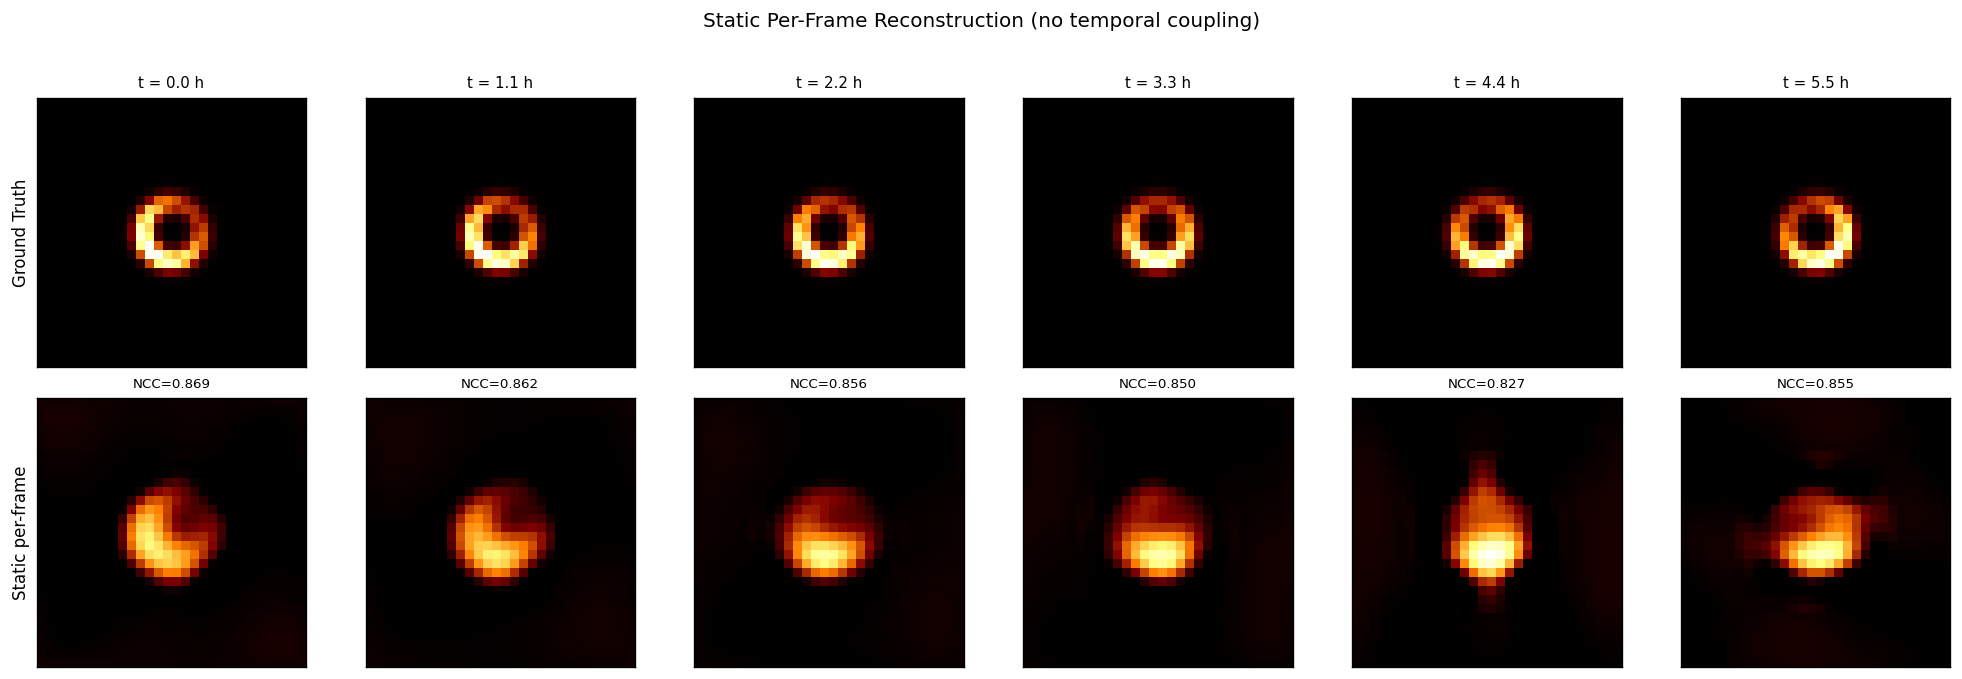

In [10]:
# Visualize static results
fig, axes = plt.subplots(2, n_show, figsize=(2.8 * n_show, 5.5))

for j, idx in enumerate(show_idx):
    # Ground truth
    axes[0, j].imshow(gt[idx], cmap='afmhot', origin='lower', vmin=0, vmax=gt.max())
    axes[0, j].set_title(f't = {frame_times[idx]:.1f} h', fontsize=9)
    axes[0, j].set_xticks([]); axes[0, j].set_yticks([])
    if j == 0:
        axes[0, j].set_ylabel('Ground Truth', fontsize=10)

    # Static reconstruction
    m = static_metrics['per_frame'][idx]
    axes[1, j].imshow(static_frames[idx], cmap='afmhot', origin='lower',
                      vmin=0, vmax=max(f.max() for f in static_frames))
    axes[1, j].set_title(f'NCC={m["ncc"]:.3f}', fontsize=8)
    axes[1, j].set_xticks([]); axes[1, j].set_yticks([])
    if j == 0:
        axes[1, j].set_ylabel('Static per-frame', fontsize=10)

fig.suptitle('Static Per-Frame Reconstruction (no temporal coupling)', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

## 7. Reconstruction: StarWarps

Now we run the full **StarWarps** EM algorithm:

1. **E-step**: Forward-backward message passing computes $E[\mathbf{x}_t]$, $E[\mathbf{x}_t \mathbf{x}_t^T]$, $E[\mathbf{x}_{t-1} \mathbf{x}_t^T]$
2. **M-step**: L-BFGS-B optimizes the warp parameters $\boldsymbol{\theta}$

This iterates for `n_em_iters` rounds.

> **Note**: This takes several minutes due to N²×N² matrix operations (900×900 matrices).

In [11]:
# StarWarps reconstruction (matching ehtim example parameters)
t0 = timer.time()

sw_solver = StarWarpsSolver(
    prior_mean=prior_mean,
    prior_cov=prior_cov,
    process_noise_cov=process_noise_cov,
    N=N, psize=psize,
    warp_method='phase',
    measurement='vis',
    n_em_iters=30,              # ehtim default: 30
    num_lin_iters=5,             # ehtim default: 5
    interior_priors=True,        # ehtim default: True
    motion_basis='affine_no_translation',  # 4 params (no translation)
    m_step_maxiter=4000,         # ehtim default: 4000
)

sw_result = sw_solver.reconstruct(models, obs)
sw_frames = sw_result['frames']

t_sw = timer.time() - t0
print(f'\nStarWarps reconstruction: {t_sw:.1f}s ({t_sw/60:.1f} min)')

# Compute metrics
sw_metrics = compute_video_metrics(sw_frames, gt)
print(f'Average NRMSE: {sw_metrics["average"]["nrmse"]:.4f}')
print(f'Average NCC:   {sw_metrics["average"]["ncc"]:.4f}')
print(f'Estimated warp theta: {sw_result["theta"]}')

StarWarps EM iteration 30/30

StarWarps reconstruction: 880.8s (14.7 min)
Average NRMSE: 0.0638
Average NCC:   0.8817
Estimated warp theta: [ 0.99943884 -0.03100496  0.03240948  0.99762995]


## 8. Comparison: Static vs StarWarps

Side-by-side comparison of both methods against ground truth.

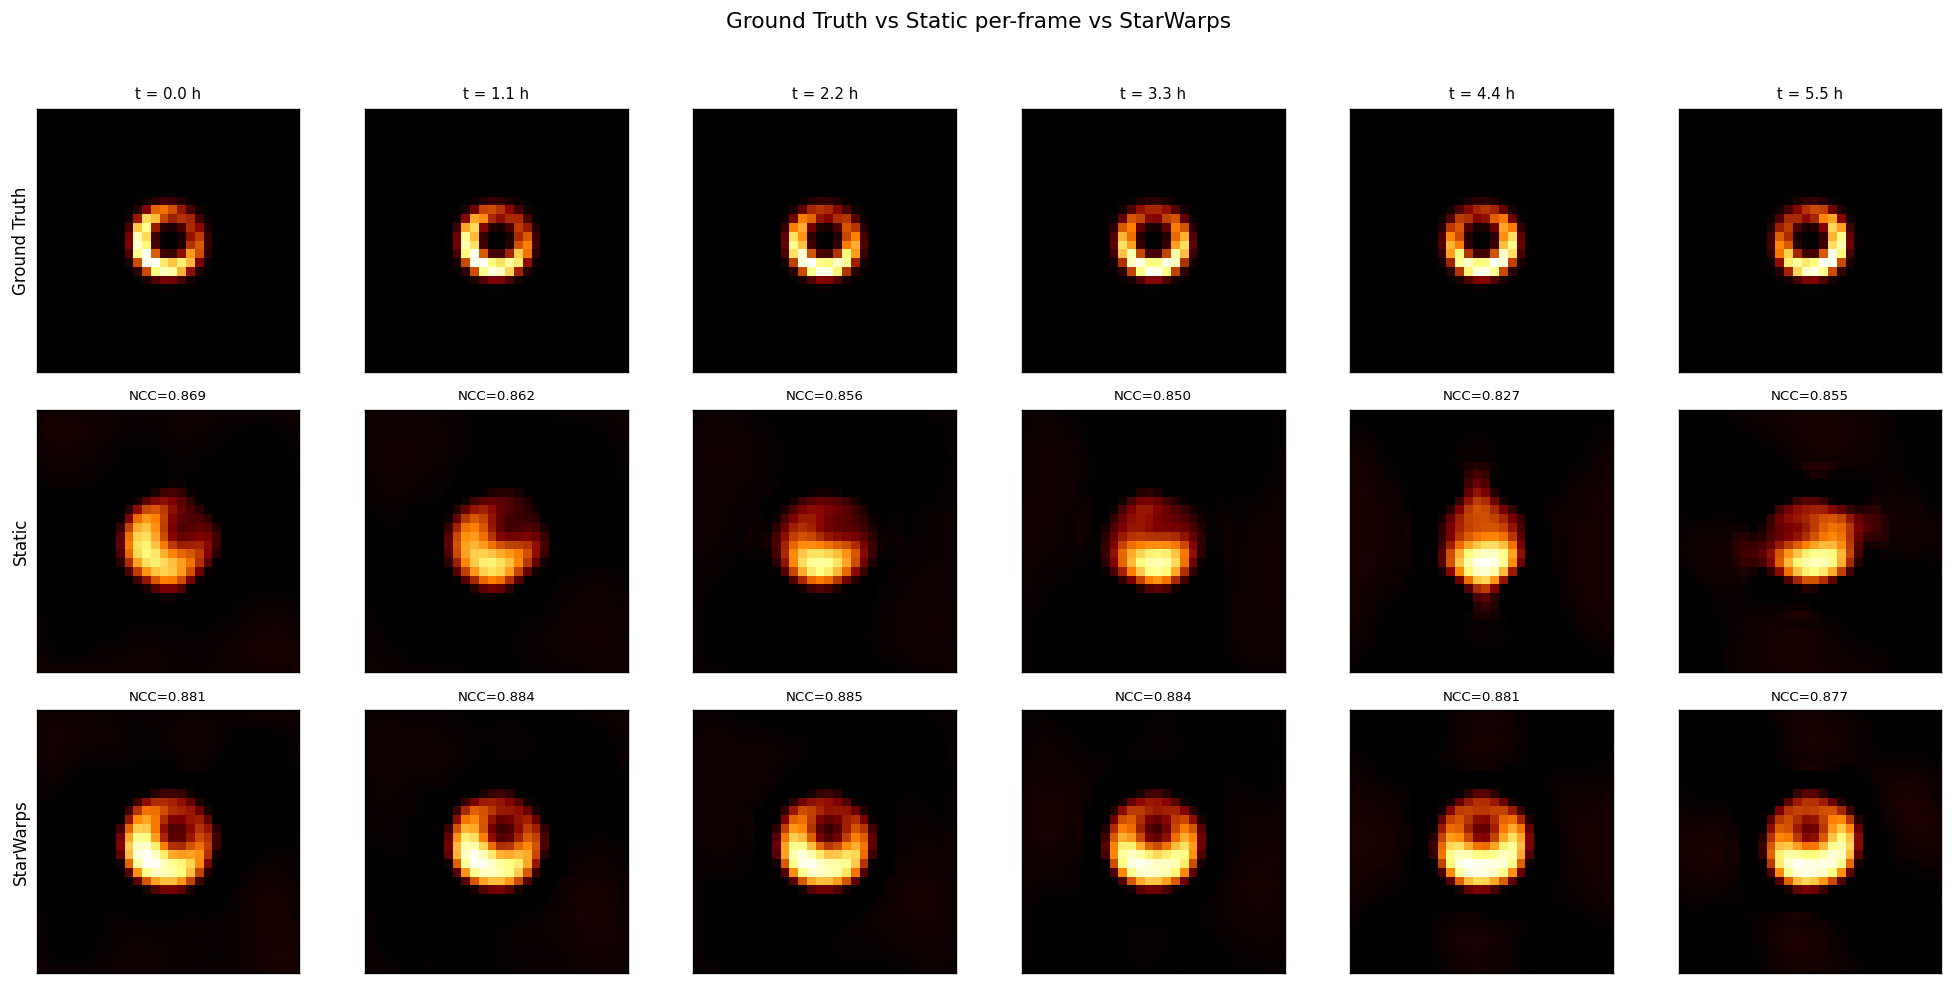

In [12]:
# Side-by-side: Ground Truth / Static / StarWarps
fig, axes = plt.subplots(3, n_show, figsize=(2.8 * n_show, 8))

vmax_gt = gt.max()
vmax_static = max(f.max() for f in static_frames)
vmax_sw = max(f.max() for f in sw_frames)

for j, idx in enumerate(show_idx):
    # Ground truth
    axes[0, j].imshow(gt[idx], cmap='afmhot', origin='lower', vmin=0, vmax=vmax_gt)
    axes[0, j].set_title(f't = {frame_times[idx]:.1f} h', fontsize=9)
    axes[0, j].set_xticks([]); axes[0, j].set_yticks([])
    if j == 0:
        axes[0, j].set_ylabel('Ground Truth', fontsize=10)

    # Static
    m_s = static_metrics['per_frame'][idx]
    axes[1, j].imshow(static_frames[idx], cmap='afmhot', origin='lower',
                      vmin=0, vmax=vmax_static)
    axes[1, j].set_title(f'NCC={m_s["ncc"]:.3f}', fontsize=8)
    axes[1, j].set_xticks([]); axes[1, j].set_yticks([])
    if j == 0:
        axes[1, j].set_ylabel('Static', fontsize=10)

    # StarWarps
    m_w = sw_metrics['per_frame'][idx]
    axes[2, j].imshow(sw_frames[idx], cmap='afmhot', origin='lower',
                      vmin=0, vmax=vmax_sw)
    axes[2, j].set_title(f'NCC={m_w["ncc"]:.3f}', fontsize=8)
    axes[2, j].set_xticks([]); axes[2, j].set_yticks([])
    if j == 0:
        axes[2, j].set_ylabel('StarWarps', fontsize=10)

fig.suptitle('Ground Truth vs Static per-frame vs StarWarps', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

In [13]:
# Metrics comparison table
metrics_all = {
    'Static per-frame': static_metrics,
    'StarWarps': sw_metrics,
}
print_metrics_table(metrics_all)


Method                           Avg NRMSE     Avg NCC
--------------------------------------------------------
Static per-frame                    0.0710      0.8507
StarWarps                           0.0638      0.8817



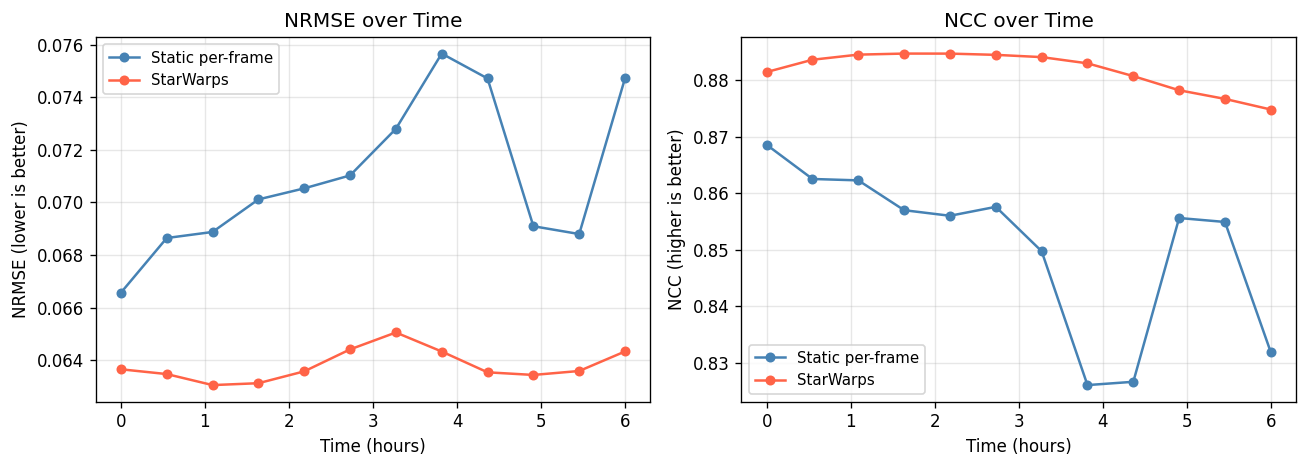

In [14]:
# Per-frame metrics over time
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

colors = {'Static per-frame': 'steelblue', 'StarWarps': 'tomato'}

for name, m in metrics_all.items():
    pf = m['per_frame']
    nrmse = [f['nrmse'] for f in pf]
    ncc = [f['ncc'] for f in pf]
    ax1.plot(frame_times, nrmse, 'o-', label=name, markersize=5, color=colors[name])
    ax2.plot(frame_times, ncc, 'o-', label=name, markersize=5, color=colors[name])

ax1.set_xlabel('Time (hours)')
ax1.set_ylabel('NRMSE (lower is better)')
ax1.set_title('NRMSE over Time')
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3)

ax2.set_xlabel('Time (hours)')
ax2.set_ylabel('NCC (higher is better)')
ax2.set_title('NCC over Time')
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 8b. Visualizing Recovered Motion (Angle × Time)

Following Bouman et al. 2017 Fig. 14, we unwrap the intensity along a fixed-radius circle
in each frame and stack them into an **angle × time** image. A rotating hot spot appears
as a diagonal stripe — its slope corresponds to the angular velocity.

This representation makes it easy to see whether the reconstruction faithfully tracks
the hot spot's rotation over time.

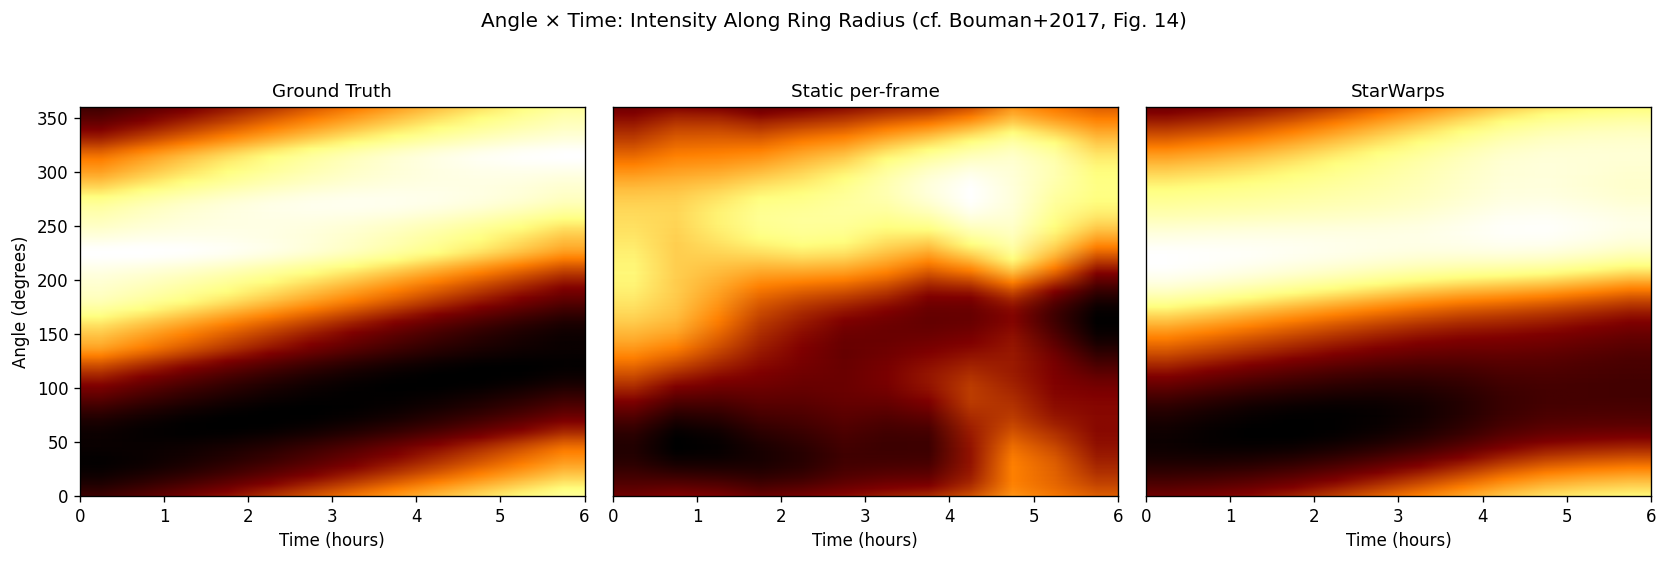

Diagonal stripe = hot spot rotating over time.
StarWarps recovers the stripe more clearly than static per-frame.


In [15]:
from src.visualization import unwrap_ring, plot_angle_time

# Angle x Time diagrams (cf. Bouman et al. 2017, Fig. 14)
# Unwrap intensity along a circle at the ring radius for each frame.
# A rotating hot spot shows as a diagonal stripe.
recon_dict = {
    'Static per-frame': np.array(static_frames),
    'StarWarps': np.array(sw_frames),
}

fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))

methods = {'Ground Truth': gt}
methods.update(recon_dict)

for i, (name, frames) in enumerate(methods.items()):
    at, angles = unwrap_ring(frames, N, psize, ring_radius_frac=0.22)
    ax = axes[i]
    ax.imshow(at, aspect='auto', cmap='afmhot', origin='lower',
              extent=[frame_times[0], frame_times[-1], 0, 360],
              interpolation='bilinear')
    ax.set_xlabel('Time (hours)', fontsize=10)
    if i == 0:
        ax.set_ylabel('Angle (degrees)', fontsize=10)
    else:
        ax.set_yticks([])
    ax.set_title(name, fontsize=11)

fig.suptitle('Angle × Time: Intensity Along Ring Radius (cf. Bouman+2017, Fig. 14)',
             fontsize=12, y=1.03)
plt.tight_layout()
plt.show()

print('Diagonal stripe = hot spot rotating over time.')
print('StarWarps recovers the stripe more clearly than static per-frame.')

## 9. StarWarps EM Convergence

The log-likelihood should increase with each EM iteration.

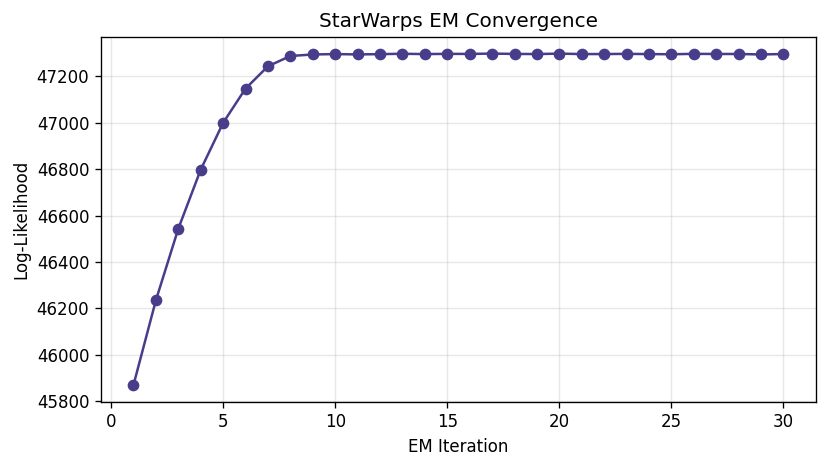

In [16]:
# Plot EM convergence
ll = sw_result['log_likelihood']

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(range(1, len(ll) + 1), ll, 'o-', color='darkslateblue', markersize=6)
ax.set_xlabel('EM Iteration')
ax.set_ylabel('Log-Likelihood')
ax.set_title('StarWarps EM Convergence')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 10. Load Pre-Computed Reference Outputs

For quick comparison without re-running the full pipeline, we can load the
pre-computed reference outputs from `evaluation/reference_outputs/`.

In [17]:
# Load reference outputs
ref_dir = os.path.join(TASK_DIR, 'evaluation', 'reference_outputs')

ref_static = np.load(os.path.join(ref_dir, 'static_reconstruction.npy'))
ref_sw = np.load(os.path.join(ref_dir, 'starwarps_reconstruction.npy'))

with open(os.path.join(ref_dir, 'metrics.json')) as f:
    ref_metrics = json.load(f)

print('Reference metrics:')
print(f'{"Method":<25s} {"Avg NRMSE":>10s} {"Avg NCC":>10s}')
print('-' * 48)
for name in ['Static per-frame', 'StarWarps']:
    avg = ref_metrics[name]['average']
    print(f'{name:<25s} {avg["nrmse"]:>10.4f} {avg["ncc"]:>10.4f}')

print(f'\nReference reconstructions loaded: static {ref_static.shape}, StarWarps {ref_sw.shape}')

Reference metrics:
Method                     Avg NRMSE    Avg NCC
------------------------------------------------
Static per-frame              0.0710     0.8507
StarWarps                     0.0638     0.8817

Reference reconstructions loaded: static (12, 30, 30), StarWarps (12, 30, 30)


## Summary

- **Static per-frame**: Each frame reconstructed independently. Quality limited by sparse UV coverage.
- **StarWarps**: Gaussian Markov model couples frames temporally. EM algorithm jointly estimates video + inter-frame motion. Achieves **higher NCC** than static baseline.

The improvement demonstrates that borrowing information across time helps overcome the under-determined nature of single-frame interferometric imaging.

### References

- Bouman et al. 2017, "Reconstructing Video from Interferometric Measurements of Time-Varying Sources", [arXiv:1711.01357](https://arxiv.org/abs/1711.01357)
- Event Horizon Telescope Collaboration, Paper IV (2019), ApJL 875, L4